# Lab Experiment 3: Machine Learning Theory and Practice


In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error



### TASK 1: Exploratory Data Analysis (EDA)

In [65]:
!pip install xlrd

In [66]:
# 1. Loading the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls"
df = pd.read_excel(url)

In [67]:
# 2. Displaying important information
# Display first 5 rows
df.head()


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [68]:
# Display dimensions
df.shape


(1030, 9)

In [69]:
# Display summary statistics
df.describe()


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136,35.817836
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912,16.705679
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.707115
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000,34.442774
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000,46.136287
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


In [70]:
# Display data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Cement (component 1)(kg in a m^3 mixture)              1030 non-null   float64
 1   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  1030 non-null   float64
 2   Fly Ash (component 3)(kg in a m^3 mixture)             1030 non-null   float64
 3   Water  (component 4)(kg in a m^3 mixture)              1030 non-null   float64
 4   Superplasticizer (component 5)(kg in a m^3 mixture)    1030 non-null   float64
 5   Coarse Aggregate  (component 6)(kg in a m^3 mixture)   1030 non-null   float64
 6   Fine Aggregate (component 7)(kg in a m^3 mixture)      1030 non-null   float64
 7   Age (day)                                              1030 non-null   int64  
 8   Concrete compressive strength(MPa, megapascals)        1030 

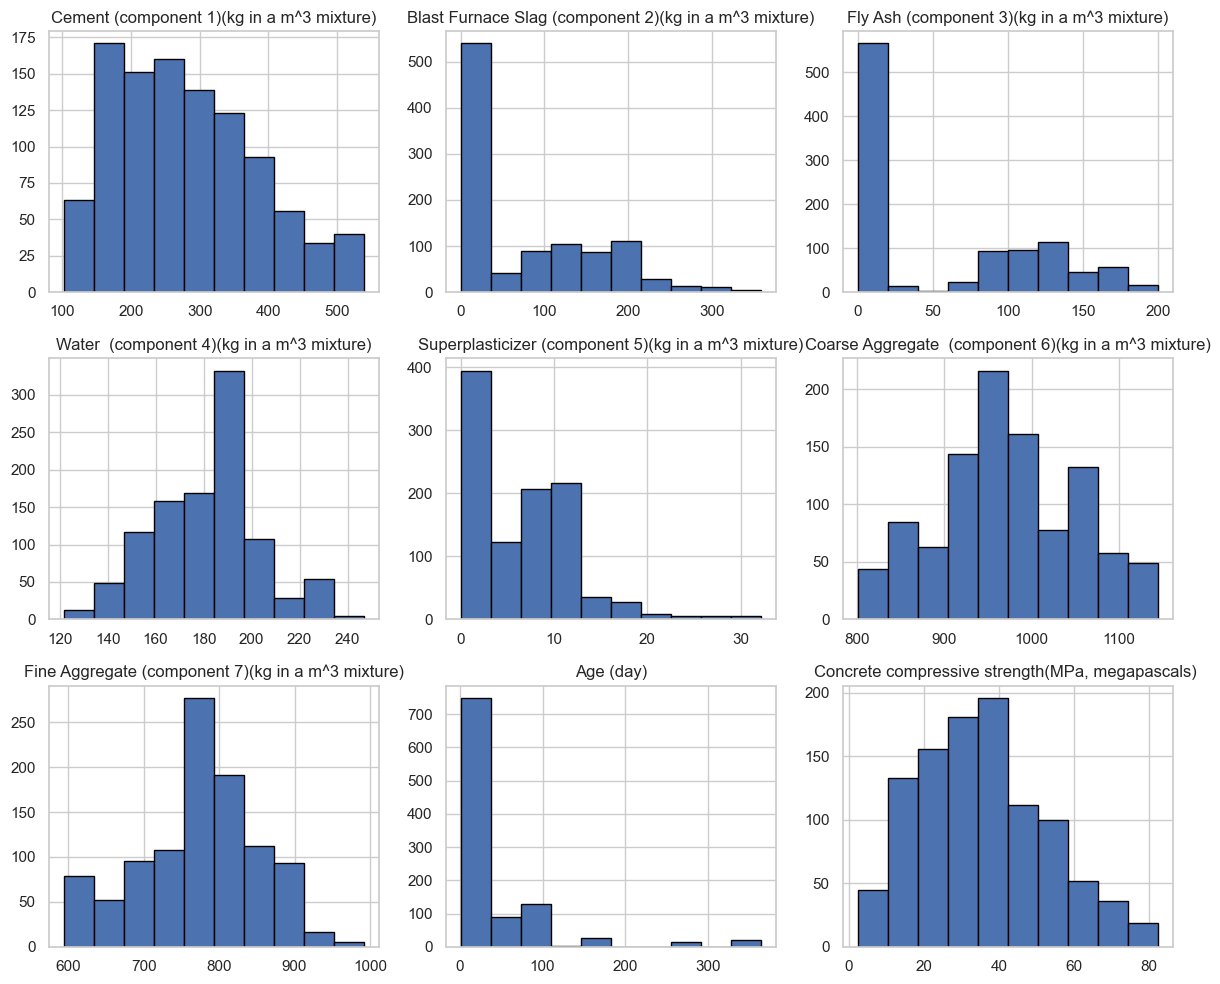

In [ ]:
# 3. Visualization of the data
df.hist(figsize=(12, 10), layout=(3,3), edgecolor='black')
plt.tight_layout()
plt.show()

### TASK 2: Data Cleaning & Transformation

In [72]:
# 1. Handling missing values
df.isnull().sum()

Cement (component 1)(kg in a m^3 mixture)                0
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    0
Fly Ash (component 3)(kg in a m^3 mixture)               0
Water  (component 4)(kg in a m^3 mixture)                0
Superplasticizer (component 5)(kg in a m^3 mixture)      0
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     0
Fine Aggregate (component 7)(kg in a m^3 mixture)        0
Age (day)                                                0
Concrete compressive strength(MPa, megapascals)          0
dtype: int64

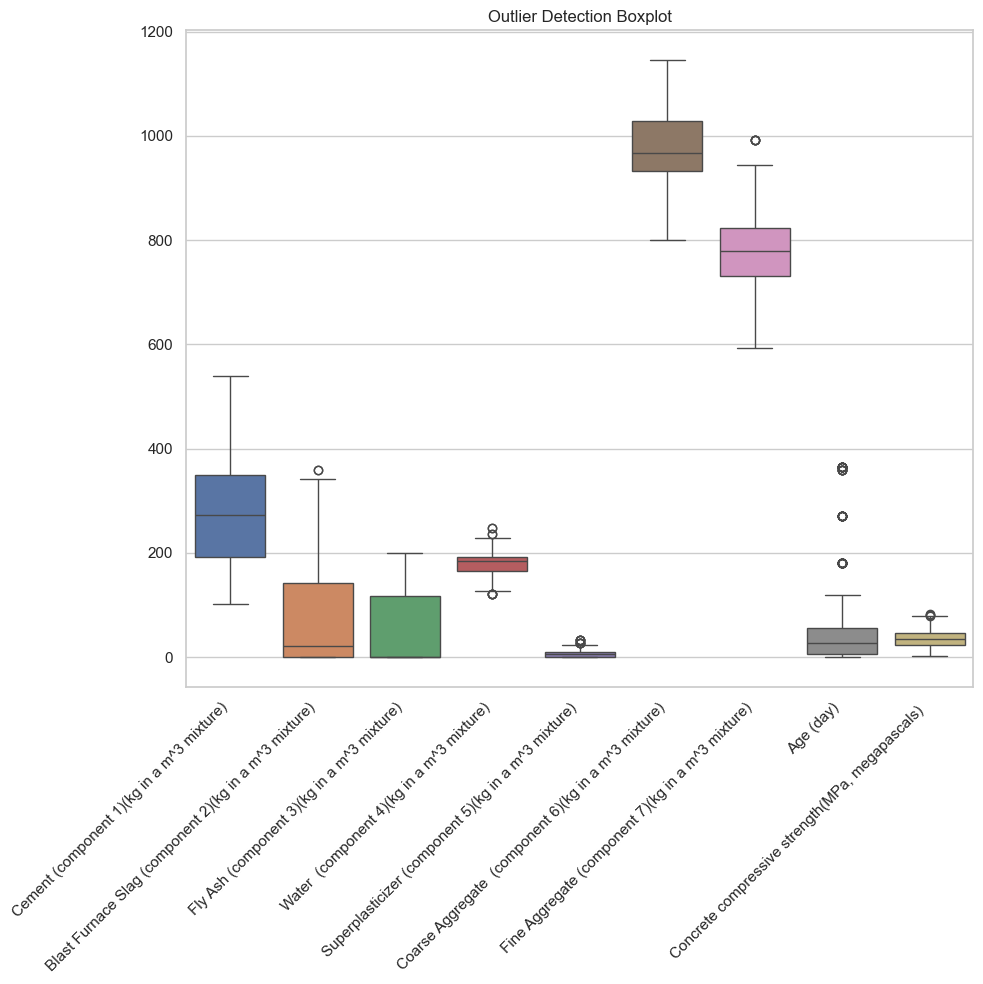

In [ ]:
# 2. Outlier detection (Visualizing with boxplot)
plt.figure(figsize=(10, 10)) 

# Creating the boxplot
sns.boxplot(data=df)

# Fixing the text visibility
plt.xticks(rotation=45, ha='right') 
plt.title("Outlier Detection Boxplot")
plt.tight_layout() 
plt.show()

In [74]:
# 3. Feature Scaling
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [75]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### TASK 3: Simple Linear Regression

In [76]:

# 1. Select one independent variable (Using 1st column: Cement)
X_simple = df.iloc[:, [0]] 
y_simple = df.iloc[:, -1]

In [77]:
# 2. Split the dataset
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_simple, y_simple, test_size=0.2, random_state=42)


In [78]:
# Build model
model_s = LinearRegression()
model_s.fit(X_train_s, y_train_s)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [79]:
# Predict
y_pred_s = model_s.predict(X_test_s)

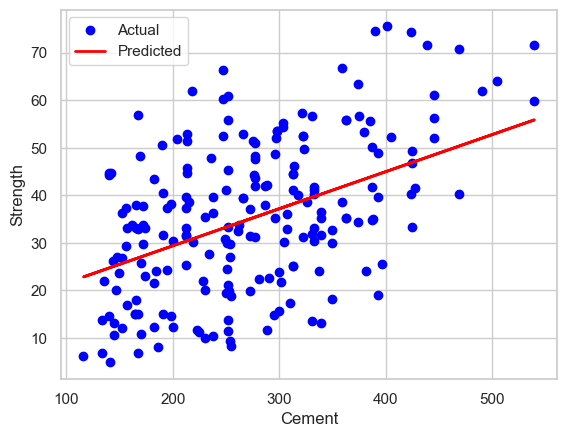

In [80]:
# 3. Plot the regression line
plt.scatter(X_test_s, y_test_s, color='blue', label='Actual')
plt.plot(X_test_s, y_pred_s, color='red', linewidth=2, label='Predicted')
plt.xlabel('Cement')
plt.ylabel('Strength')
plt.legend()
plt.show()

In [81]:
# 4. Evaluate
print("Simple Linear Regression Metrics:")
print(f"R2 Score: {r2_score(y_test_s, y_pred_s)}")
print(f"MAE: {mean_absolute_error(y_test_s, y_pred_s)}")
print(f"MSE: {mean_squared_error(y_test_s, y_pred_s)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_s, y_pred_s))}")

Simple Linear Regression Metrics:
R2 Score: 0.25183140674244187
MAE: 11.555820769998833
MSE: 192.78889718821986
RMSE: 13.884844154264744


### TASK 4: Multiple Linear Regression

In [82]:
# 1. Build model using multiple features
X_multi = X_scaled
y_multi = y


In [83]:
# Split the dataset
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

In [84]:
model_m = LinearRegression()
model_m.fit(X_train_m, y_train_m)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [85]:

# 2. Predict
y_pred_m = model_m.predict(X_test_m)

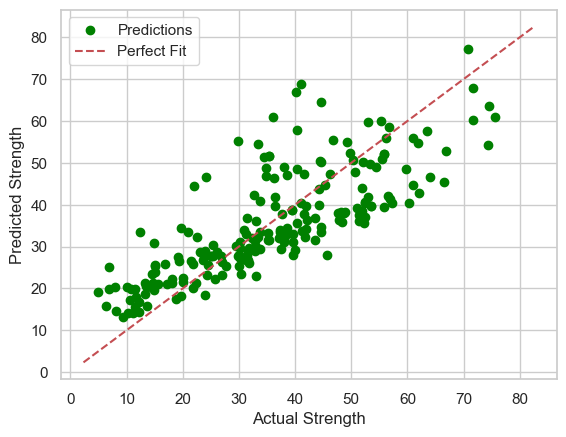

In [86]:
# 3. Plot regression line (Actual vs Predicted)
plt.scatter(y_test_m, y_pred_m, color='green', label='Predictions')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Perfect Fit')
plt.xlabel('Actual Strength')
plt.ylabel('Predicted Strength')
plt.legend()
plt.show()

In [87]:
# 4. Evaluate
print("\nMultiple Linear Regression Metrics:")
print(f"R2 Score: {r2_score(y_test_m, y_pred_m)}")
print(f"MAE: {mean_absolute_error(y_test_m, y_pred_m)}")
print(f"MSE: {mean_squared_error(y_test_m, y_pred_m)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_m, y_pred_m))}")


Multiple Linear Regression Metrics:
R2 Score: 0.6275416055429017
MAE: 7.745392872421347
MSE: 95.97548435337715
RMSE: 9.79670783239845
